# NB05a2 — Data Stack Audit and Date Prune

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.



| Field | Value |
|-------|-------|
| **Notebook** | `05a2_bda_DataStack_Audit_Prune_v6.ipynb` |
| **Version** | v6 |
| **Pipeline position** | QA. After NB05a (data stack built), before NB05b (parquet creation). |
| **Last validated** | 2026-04-XX |

## Narrative

Self-contained scan + date prune + corrupt detection for `STACK_DIR/{city}/`.
Same three-pass approach as NB03d (source products) and NB03f (derived products),
but operating on the data_stack copy — the final check before parquet creation.

**Mostly redundant if NB01-NB04 pipeline ran cleanly.** Exists as a safety net to
catch issues introduced during NB05a alignment: wrong-date TIFs from filename
parsing errors, truncated TIFs from interrupted copy operations, or leftover files
from previous runs with different tier/city selections.

### Pipeline
1. **SCAN**: Count TIFs per city, extract dates, classify by sensor (CARD/COH/MS/derived)
2. **DATE-PLAN**: Flag TIFs whose dates are NOT in `nb02a_scene_plan.json` (portable copy in stack)
3. **DATE-SCAN**: Flag TIFs with dates outside the battle window +/- buffer
4. **CORRUPT-SCAN**: Open each TIF with rasterio to verify readability (catches truncated files that crashed NB03e R2)
5. **PRUNE**: Delete flagged TIFs (merge DATE-PLAN + DATE-SCAN + CORRUPT candidates)
6. **SQLITE**: Sync results to bda.sqlite

## Thresholds

| Parameter | Value | Justification |
|-----------|-------|---------------|
| `BUFFER_DAYS_PRE` | 550 days | ~18 months before battle_start. Covers Dietrich 12-month baseline + margin. |
| `BUFFER_DAYS_POST` | 550 days | ~18 months after battle_stop. Covers assessment + recovery monitoring. |
| `CORRUPT_SAMPLE_PER_CITY` | 0 (=all) | Check every TIF. Corrupt detection is fast (~0.01s per TIF). |

## Inputs

| Data | Source | Format |
|------|--------|--------|
| Data stack TIFs | `STACK_DIR/{city}/` (NB05a) | GeoTIFF |
| `nb02a_scene_plan.json` | `STACK_DIR/` (portable copy from NB05a) | JSON |
| `cities_config.json` | Manual | JSON (battle dates) |

## Outputs

| Artifact | Path | Used by |
|----------|------|---------|
| Deleted TIFs (if DRY_RUN=False) | Removed from `STACK_DIR/` | Disk reclamation |
| `bda.sqlite` (stack_audit table) | `CATALOG_DB` | Audit trail |
| Audit report (in-notebook) | — | Operator review |

## Cell Structure

| Cell | ID | What | Lines | Status |
|------|----|------|-------|--------|
| 0 | — | Documentation (this cell) | — | — |
| 1 | CONFIG | Config (DRY_RUN, BUFFER_DAYS, CORRUPT flags) | 10 | Config |
| 2 | SETUP | Load global_setup | 10 | Config |
| 3 | SCAN | Count data stack TIFs per city | 135 | **Core** |
| 4 | PLAN-LOAD | Read scene plan (stack copy or OUTPUTS) | 63 | **Core** |
| 5 | DATE-PLAN | Flag TIFs not in plan | 64 | **Core** |
| 6 | DATE-SCAN | Flag TIFs outside battle window | 35 | **Core** |
| 7 | CORRUPT-SCAN | rasterio.open readability test | 61 | **Core** |
| 8 | PRUNE | Delete flagged TIFs (DATE + CORRUPT merged) | 83 | Optional |
| 9 | SQLITE | Sync to bda.sqlite | 80 | **Core** |
| 10 | SUMMARY | Completion report | 20 | QA |

## Thesis Mapping

| Thesis Section | Cells | Content |
|----------------|-------|---------|
| 3.4 Dataset Construction — Quality Gate | All | Final data stack validation before feature extraction |

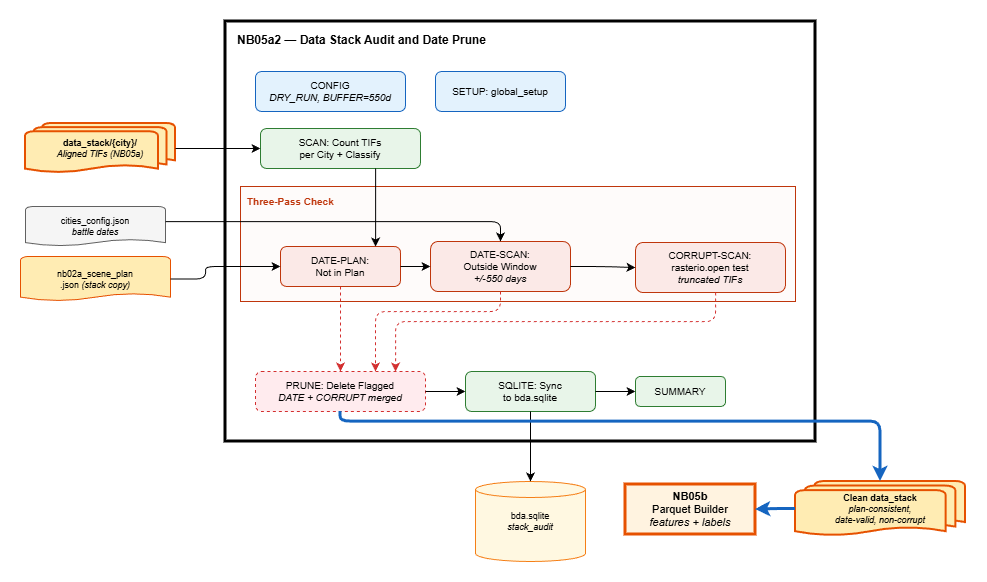

In [1]:
# @title CELL CONFIG
NOTEBOOK_ID = 'NB05a2'
TIER_SELECTION = [0,1,2,3,4,5]
DRY_RUN = False               # True = report only, False = delete
BUFFER_DAYS_PRE = 550         # days before battle_start to keep
BUFFER_DAYS_POST = 550        # days after battle_stop to keep
VERBOSE = True
CITY_FILTER = None            # None = all cities, or list e.g. ['Mariupol']
CHECK_CORRUPT = True          # True = rasterio.open test on dated TIFs
CORRUPT_SAMPLE_PER_CITY = 0   # 0 = check ALL dated TIFs, N = random sample per city

# ---- SENTINEL CONTAMINATION (S1 + S2) ----
# S1: raw SAR scenes in data_stack with fraction of sentinel pixels >= threshold.
#     Edge-of-swath (<80% sentinel) kept; NB06+ handles those per-pixel.
# S2: derived products (composites, baselines, accumulators, z-scores, NBR,
#     landuse, rolling/block stats) with ANY sentinel pixel flagged, because
#     a single -100 in an aggregate skews means arbitrarily.
ENABLE_S1_SENTINEL_PRIMARY = True
ENABLE_S2_SENTINEL_DERIVED = True
SENTINEL_CUT = -99.0                    # values <= -99 treated as sentinel
SENTINEL_FRAC_PRIMARY = 0.80            # S1 threshold for raw SAR
SENTINEL_DOWNSAMPLE = 500               # NxN downsampled read for S1 (~36x faster)
SENTINEL_DERIVED_MIN_PX = 1             # S2: min sentinel pixels in derived to flag

In [2]:
# @title CELL SETUP: LOAD GLOBAL ENVIRONMENT
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())

/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


BDA GLOBAL SETUP
Started: 2026-04-20 19:41:06
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------
  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2, 3, 4, 5]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: False
  CITIES_TO_PROCESS: 50 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:545: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     912.7/7452.0 GB (6539.3 GB free)
  GDrive (F:)     1327.1/3726.0 GB (2398.9 GB free)
  Local data      11527.1/14901.9 GB (3374.7 GB free)
  Data stack      1327.1/3726.0 GB (2398.9 GB free)
  WSL ext4        95.1/1006.9 GB (860.5 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 50, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

In [3]:
# @title CELL SCAN: COUNT DATA STACK TIFs PER CITY
import re
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict, Counter

print('=' * 80)
print('SCAN: DATA STACK')
print('=' * 80)
print(f'  STACK_DIR: {STACK_DIR}')

RE_DATE8 = re.compile(r'(\d{8})')

def load_battle_dates(city_name):
    aoi_path = CITIES_DIR / city_name / 'AOI.geojson'
    if not aoi_path.exists():
        return None, None, None
    with open(str(aoi_path), 'r') as f:
        raw = f.read(50000)
    bs = be = tier = None
    m = re.search(r'"battle_start"\s*:\s*"([^"]+)"', raw)
    if m:
        try: bs = datetime.strptime(m.group(1)[:10], '%Y-%m-%d')
        except ValueError: pass
    m = re.search(r'"battle_stop"\s*:\s*"([^"]+)"', raw)
    if m and m.group(1) != 'ongoing':
        try: be = datetime.strptime(m.group(1)[:10], '%Y-%m-%d')
        except ValueError: pass
    m = re.search(r'"tier"\s*:\s*(\d+)', raw)
    if m: tier = int(m.group(1))
    return bs, be, tier

def extract_dates(fname):
    dates = []
    for m in RE_DATE8.finditer(fname):
        try:
            dt = datetime.strptime(m.group(1), '%Y%m%d')
            if 2015 <= dt.year <= 2030:
                dates.append(dt)
        except ValueError: pass
    return dates

def classify_sensor(fname):
    fl = fname.lower()
    if fl.startswith('s1__coh'): return 'COH'
    if fl.startswith('s1__card') or fl.startswith('s1__vv') or fl.startswith('s1__vh'): return 'CARD'
    if fl.startswith('s2__'): return 'MS'
    if fl.startswith('landuse__') or fl.startswith('lulc__'): return 'LANDUSE'
    if fl.startswith('bldg__') or fl.startswith('building'): return 'BUILDING'
    if fl.startswith('damage') or fl.startswith('unosat'): return 'LABEL'
    if 'coh' in fl: return 'COH'
    if 'card' in fl or 'backscatter' in fl: return 'CARD'
    if any(b in fl for b in ['_b02','_b03','_b04','_b05','_b06','_b07','_b08','_b8a','_b11','_b12','_scl']): return 'MS'
    if any(k in fl for k in ['ndvi','nbr','bsi','ndwi']): return 'INDEX'
    if 'composite' in fl or 'rgb' in fl: return 'COMPOSITE'
    if 'rolling' in fl or 'zscore' in fl or 'baseline' in fl: return 'TEMPORAL'
    return 'OTHER'

def is_outside_window(dates, win_start, win_end):
    if not dates: return False, ''
    all_outside = True
    reason_parts = []
    for dt in dates:
        dt_outside = False
        if win_start and dt < win_start:
            dt_outside = True
            reason_parts.append(f'{dt.strftime("%Y-%m-%d")} before {win_start.strftime("%Y-%m-%d")}')
        elif win_end and dt > win_end:
            dt_outside = True
            reason_parts.append(f'{dt.strftime("%Y-%m-%d")} after {win_end.strftime("%Y-%m-%d")}')
        if not dt_outside:
            all_outside = False
    return all_outside, '; '.join(reason_parts)

# cache battle dates
_bd_cache = {}
def get_bd(city):
    if city not in _bd_cache:
        _bd_cache[city] = load_battle_dates(city)
    return _bd_cache[city]

# scan
city_dirs = sorted([d for d in STACK_DIR.iterdir() if d.is_dir()
                    and d.name not in ('metadata','desktop.ini','dataset','.ipynb_checkpoints')])
if CITY_FILTER:
    city_dirs = [d for d in city_dirs if d.name in CITY_FILTER]

scan_results = []
all_tif_info = []  # (city, tif_path, dates, sensor, fsize)

for city_dir in city_dirs:
    city = city_dir.name
    bs, be, tier = get_bd(city)
    tifs = list(city_dir.rglob('*.tif'))
    sensor_counts = defaultdict(int)
    total_bytes = 0
    dated = 0
    undated = 0
    for tif in tifs:
        sensor = classify_sensor(tif.name)
        sensor_counts[sensor] += 1
        fsize = tif.stat().st_size
        total_bytes += fsize
        dates = extract_dates(tif.name)
        if dates: dated += 1
        else: undated += 1
        all_tif_info.append((city, tif, dates, sensor, fsize))
    scan_results.append({
        'city': city, 'tier': tier,
        'battle_start': bs.strftime('%Y-%m-%d') if bs else None,
        'battle_stop': be.strftime('%Y-%m-%d') if be else 'ongoing',
        'total_tifs': len(tifs), 'total_mb': total_bytes/(1024*1024),
        'dated': dated, 'undated': undated,
        'sensors': dict(sensor_counts),
    })

# print table
print(f'\n  {"City":<22s} {"T":>2s} {"TIFs":>5s} {"MB":>8s} {"dated":>6s} {"undat":>6s} {"battle_start":>13s} {"battle_stop":>13s}')
print(f'  {"-"*22} {"-"*2} {"-"*5} {"-"*8} {"-"*6} {"-"*6} {"-"*13} {"-"*13}')
for r in scan_results:
    t = str(r['tier']) if r['tier'] is not None else '?'
    print(f'  {r["city"]:<22s} {t:>2s} {r["total_tifs"]:>5d} {r["total_mb"]:>8.1f} {r["dated"]:>6d} {r["undated"]:>6d} {r["battle_start"] or "":>13s} {r["battle_stop"] or "":>13s}')

t_tifs = sum(r['total_tifs'] for r in scan_results)
t_mb = sum(r['total_mb'] for r in scan_results)
print(f'  {"-"*22} {"-"*2} {"-"*5} {"-"*8}')
print(f'  {"TOTAL":<22s} {"":>2s} {t_tifs:>5d} {t_mb:>8.1f}')

# sensor breakdown
print(f'\n--- Sensor breakdown ---')
gs = defaultdict(int)
for r in scan_results:
    for s, c in r['sensors'].items(): gs[s] += c
for s in sorted(gs.keys()):
    print(f'  {s:<12s}: {gs[s]:>6d} TIFs')

SCAN: DATA STACK
  STACK_DIR: /mnt/f/PROJECTS/masterthesis/data_stack

  City                    T  TIFs       MB  dated  undat  battle_start   battle_stop
  ---------------------- -- ----- -------- ------ ------ ------------- -------------
  Avdiivka                2  2780   7068.4   1635   1145    2022-02-24    2024-02-17
  BRIGHT_64               ? 13588     21.5      0  13588                     ongoing
  Bakhmut                 3  1662   5731.6    944    718    2022-05-17    2023-05-20
  Balakliia               3  1720   3595.3    880    840    2022-03-03    2022-09-08
  Borodyanka              1   243   5251.0     85    158    2022-02-28    2022-04-01
  Bucha                   1   766   1233.2    442    324    2022-02-27    2022-03-31
  Chasiv Yar              5  2461  50949.4   1716    745    2023-06-01       ongoing
  Chernihiv               1   634   2712.5    362    272    2022-02-24    2022-04-04
  Chornobaivka            2  1170   4730.7    756    414    2022-02-24    2022-

In [4]:
# @title CELL PLAN-LOAD: READ UNIFIED SCENE PLAN (DATA_STACK OR OUTPUTS)
import json as _json

print('=' * 80)
print('PLAN-LOAD: READ UNIFIED SCENE PLAN')
print('=' * 80)

# try data_stack copy first (portable), then OUTPUTS_DIR
_plan_path = STACK_DIR / 'nb02a_scene_plan.json'
if not _plan_path.exists():
    _plan_path = OUTPUTS_DIR / 'nb02a_scene_plan.json'

if not _plan_path.exists():
    print(f'  WARNING: Plan not found. DATE-PLAN check will be skipped.')
    print(f'  Tried: {STACK_DIR / "nb02a_scene_plan.json"}')
    print(f'  Tried: {OUTPUTS_DIR / "nb02a_scene_plan.json"}')
    PLAN = {}
else:
    with open(_plan_path) as f:
        PLAN = _json.load(f)
    print(f'  Plan: {_plan_path}')
    print(f'  Cities in plan: {len(PLAN)}')

# Build plan date lookups per city per modality
plan_dates_ms = {}
plan_dates_card = {}
plan_dates_coh_pairs = {}

for city, p in PLAN.items():
    ms_dates = set()
    for entry in p.get('ms', []):
        d = entry.get('date', '')[:10].replace('-', '')
        if len(d) == 8:
            ms_dates.add(d)
    plan_dates_ms[city] = ms_dates

    card_dates = set()
    for entry in p.get('card', []):
        actual = entry.get('actual_date', '')[:10].replace('-', '')
        planned = entry.get('date', '')[:10].replace('-', '')
        d = actual if len(actual) == 8 else planned
        if len(d) == 8:
            card_dates.add(d)
    plan_dates_card[city] = card_dates

    slc_dates = sorted(set(
        entry.get('date', '')[:10].replace('-', '')
        for entry in p.get('slc', [])
        if len(entry.get('date', '')[:10].replace('-', '')) == 8
    ))
    pairs = set()
    for i in range(len(slc_dates) - 1):
        pairs.add((slc_dates[i], slc_dates[i + 1]))
    plan_dates_coh_pairs[city] = pairs

n_ms = sum(len(v) for v in plan_dates_ms.values())
n_card = sum(len(v) for v in plan_dates_card.values())
n_coh = sum(len(v) for v in plan_dates_coh_pairs.values())
print(f'  MS dates:   {n_ms}')
print(f'  CARD dates: {n_card}')
print(f'  COH pairs:  {n_coh}')
print('=' * 80)


PLAN-LOAD: READ UNIFIED SCENE PLAN
  Plan: /mnt/f/PROJECTS/masterthesis/data_stack/nb02a_scene_plan.json
  Cities in plan: 50
  MS dates:   1392
  CARD dates: 2272
  COH pairs:  2222


In [5]:
# @title CELL DATE-PLAN: FIND DATA_STACK TIFs NOT IN PLAN
import re

print('=' * 80)
print('DATE-PLAN: DATA_STACK TIFs NOT IN PLAN')
print('=' * 80)

if not PLAN:
    print('  SKIPPED (no plan loaded)')
    plan_date_prune_candidates = []
else:
    date_re = re.compile(r'(\d{8})')
    plan_date_prune_candidates = []

    for city, tif, dates, sensor, fsize in all_tif_info:
        if not dates:
            continue
        if city not in PLAN:
            continue

        all_dates_str = [d.strftime('%Y%m%d') for d in dates]

        if sensor == 'CARD':
            valid = plan_dates_card.get(city, set())
            if not any(d in valid for d in all_dates_str):
                plan_date_prune_candidates.append((
                    city, tif, dates,
                    f'CARD date(s) {",".join(all_dates_str)} not in plan'))

        elif sensor == 'MS':
            valid = plan_dates_ms.get(city, set())
            if not any(d in valid for d in all_dates_str):
                plan_date_prune_candidates.append((
                    city, tif, dates,
                    f'MS date(s) {",".join(all_dates_str)} not in plan'))

        elif sensor == 'COH':
            if len(all_dates_str) >= 2:
                d1, d2 = sorted(all_dates_str[:2])
                valid_pairs = plan_dates_coh_pairs.get(city, set())
                if (d1, d2) not in valid_pairs and (d2, d1) not in valid_pairs:
                    plan_date_prune_candidates.append((
                        city, tif, dates,
                        f'COH pair {d1}_{d2} not in plan'))

    print(f'  Plan-date candidates: {len(plan_date_prune_candidates)}')
    if plan_date_prune_candidates:
        total_mb = sum(t.stat().st_size for _, t, _, _ in plan_date_prune_candidates if t.exists()) / (1024*1024)
        print(f'  Total size: {total_mb:.1f} MB')
        from collections import Counter
        cc = Counter(c for c, _, _, _ in plan_date_prune_candidates)
        print(f'\n  Per-city:')
        for city in sorted(cc.keys()):
            print(f'    {city:<22s}: {cc[city]:>4d} files')
        if VERBOSE:
            print(f'\n  Sample:')
            for city, tif, dates, reason in plan_date_prune_candidates[:20]:
                print(f'    {city:<20s} {tif.name:<55s}  {reason}')
            if len(plan_date_prune_candidates) > 20:
                print(f'    ... and {len(plan_date_prune_candidates) - 20} more')
    else:
        print('  All data_stack TIFs match plan dates -- PASS')
print('=' * 80)


DATE-PLAN: DATA_STACK TIFs NOT IN PLAN
  Plan-date candidates: 153
  Total size: 823.1 MB

  Per-city:
    Avdiivka              :    5 files
    Mariupol              :  148 files

  Sample:
    Avdiivka             s1__vh__20210102.tif                                     CARD date(s) 20210102 not in plan
    Avdiivka             s1__vh__20210108.tif                                     CARD date(s) 20210108 not in plan
    Avdiivka             s1__vv__20210102.tif                                     CARD date(s) 20210102 not in plan
    Avdiivka             s1__vv__20210108.tif                                     CARD date(s) 20210108 not in plan
    Avdiivka             s1__vv__20210114.tif                                     CARD date(s) 20210114 not in plan
    Mariupol             s1__vh__20220103.tif                                     CARD date(s) 20220103 not in plan
    Mariupol             s1__vh__20220115.tif                                     CARD date(s) 20220115 not in p

In [6]:
# @title CELL DATE-SCAN: FIND TIFs WITH DATES OUTSIDE BATTLE WINDOW

print('=' * 80)
print('DATE-SCAN: TIFs OUTSIDE BATTLE WINDOW')
print('=' * 80)
print(f'  Buffer: {BUFFER_DAYS_PRE}d pre / {BUFFER_DAYS_POST}d post')

date_prune_candidates = []  # (city, tif_path, dates, reason)

for city, tif, dates, sensor, fsize in all_tif_info:
    if not dates:
        continue
    bs, be, _ = get_bd(city)
    win_start = (bs - timedelta(days=BUFFER_DAYS_PRE)) if bs else None
    win_end = (be + timedelta(days=BUFFER_DAYS_POST)) if be else None
    outside, reason = is_outside_window(dates, win_start, win_end)
    if outside:
        date_prune_candidates.append((city, tif, dates, reason))

print(f'\n  Date-prune candidates: {len(date_prune_candidates)}')
if date_prune_candidates:
    total_mb = sum(t.stat().st_size for _, t, _, _ in date_prune_candidates) / (1024*1024)
    print(f'  Total size: {total_mb:.1f} MB')
    cc = Counter(c for c, _, _, _ in date_prune_candidates)
    print(f'\n  Per-city:')
    for city in sorted(cc.keys()):
        bs, be, _ = get_bd(city)
        print(f'    {city:<22s}: {cc[city]:>4d} files  '
              f'(battle: {bs.strftime("%Y-%m-%d") if bs else "?"} -> {be.strftime("%Y-%m-%d") if be else "ongoing"})')
    if VERBOSE:
        print(f'\n  First 30:')
        for city, tif, dates, reason in date_prune_candidates[:30]:
            print(f'    {city:<20s} {tif.name:<55s}  {reason}')
        if len(date_prune_candidates) > 30:
            print(f'    ... and {len(date_prune_candidates) - 30} more')

DATE-SCAN: TIFs OUTSIDE BATTLE WINDOW
  Buffer: 550d pre / 550d post

  Date-prune candidates: 648
  Total size: 2934.6 MB

  Per-city:
    Bakhmut               :   28 files  (battle: 2022-05-17 -> 2023-05-20)
    Bucha                 :   84 files  (battle: 2022-02-27 -> 2022-03-31)
    Chernihiv             :   56 files  (battle: 2022-02-24 -> 2022-04-04)
    Dmytrivka             :   58 files  (battle: 2022-02-27 -> 2022-03-31)
    Hirske                :   28 files  (battle: 2022-06-01 -> 2022-07-04)
    Hostomel              :   84 files  (battle: 2022-02-24 -> 2022-04-02)
    Irpin                 :   58 files  (battle: 2022-02-27 -> 2022-03-28)
    Lysychansk            :   28 files  (battle: 2022-06-25 -> 2022-07-03)
    Makariv               :   84 files  (battle: 2022-02-28 -> 2022-03-22)
    Moschun               :   84 files  (battle: 2022-02-27 -> 2022-03-31)
    Rubizhne              :   28 files  (battle: 2022-03-04 -> 2022-05-12)
    Sievierodonetsk       :   28 files 

In [7]:
# @title CELL CORRUPT-SCAN: FIND TRUNCATED / UNREADABLE TIFs
# Opens each dated TIF with rasterio to check if it is readable.
# Catches the exact error that crashed NB03e R2 (TIFF offset 8 / truncated files).

import rasterio
import random

print('=' * 80)
print('CORRUPT-SCAN: CHECK TIF READABILITY')
print('=' * 80)
print(f'  CHECK_CORRUPT: {CHECK_CORRUPT}')
print(f'  CORRUPT_SAMPLE_PER_CITY: {CORRUPT_SAMPLE_PER_CITY} (0=all)')

corrupt_candidates = []  # (city, tif_path, error_msg)

if CHECK_CORRUPT:
    # group dated TIFs by city
    city_dated_tifs = defaultdict(list)
    for city, tif, dates, sensor, fsize in all_tif_info:
        if dates:
            city_dated_tifs[city].append(tif)

    total_checked = 0
    for city in sorted(city_dated_tifs.keys()):
        tifs = city_dated_tifs[city]
        # tiny files are always corrupt
        tiny = [t for t in tifs if t.stat().st_size < 1024]
        for t in tiny:
            corrupt_candidates.append((city, t, f'tiny file ({t.stat().st_size} bytes)'))

        # rasterio check on remaining
        check_tifs = [t for t in tifs if t.stat().st_size >= 1024]
        if CORRUPT_SAMPLE_PER_CITY > 0 and len(check_tifs) > CORRUPT_SAMPLE_PER_CITY:
            check_tifs = random.sample(check_tifs, CORRUPT_SAMPLE_PER_CITY)

        city_corrupt = 0
        for tif in check_tifs:
            total_checked += 1
            try:
                with rasterio.open(tif) as src:
                    _ = src.read(1, window=rasterio.windows.Window(0, 0, 1, 1))
            except Exception as e:
                err = str(e)[:100]
                corrupt_candidates.append((city, tif, err))
                city_corrupt += 1

        if city_corrupt > 0:
            print(f'  {city:<22s}: {city_corrupt} corrupt out of {len(check_tifs)} checked')

    print(f'\n  Checked: {total_checked} TIFs')
    print(f'  Corrupt: {len(corrupt_candidates)}')
    if corrupt_candidates:
        total_corrupt_mb = sum(t.stat().st_size for _, t, _ in corrupt_candidates) / (1024*1024)
        print(f'  Corrupt size: {total_corrupt_mb:.1f} MB')
        if VERBOSE:
            for city, tif, err in corrupt_candidates[:20]:
                print(f'    {city:<20s} {tif.name:<50s} {err}')
            if len(corrupt_candidates) > 20:
                print(f'    ... and {len(corrupt_candidates) - 20} more')
else:
    print('  SKIPPED (CHECK_CORRUPT=False)')

CORRUPT-SCAN: CHECK TIF READABILITY
  CHECK_CORRUPT: True
  CORRUPT_SAMPLE_PER_CITY: 0 (0=all)

  Checked: 53554 TIFs
  Corrupt: 4
  Corrupt size: 0.0 MB
    Pisky                s2__rgb_prepost__post__20220831.tif                tiny file (621 bytes)
    Pisky                s2__rgb_prepost__pre__20220108.tif                 tiny file (621 bytes)
    Robotyne             s2__rgb_prepost__post__20230923.tif                tiny file (621 bytes)
    Robotyne             s2__rgb_prepost__pre__20230210.tif                 tiny file (624 bytes)


In [9]:
# @title CELL S1-SENTINEL-PRIMARY: RAW SAR SCENES WITH >=80% SENTINEL
# Full-raster check on raw CARD/COH TIFs already copied into data_stack.
# Uses downsampled read (NxN) for speed; nearest-neighbor preserves sentinels.
# Edge-of-swath scenes (<80% sentinel) kept for NB06+ per-pixel NaN handling.
import rasterio
from rasterio.enums import Resampling
import numpy as np
import time as _time
print('=' * 80)
print('S1-SENTINEL-PRIMARY: RAW SAR SCENES WITH SENTINEL FLOOD')
print('=' * 80)
print(f'  ENABLE_S1:             {ENABLE_S1_SENTINEL_PRIMARY}')
print(f'  SENTINEL_CUT:          {SENTINEL_CUT}')
print(f'  SENTINEL_FRAC_PRIMARY: {SENTINEL_FRAC_PRIMARY} ({SENTINEL_FRAC_PRIMARY*100:.0f}%)')
print(f'  SENTINEL_DOWNSAMPLE:   {SENTINEL_DOWNSAMPLE}x{SENTINEL_DOWNSAMPLE}')
sentinel_primary_candidates = []  # (city, tif, reason)
if ENABLE_S1_SENTINEL_PRIMARY:
    t0 = _time.time()
    n_checked = 0
    per_city = defaultdict(int)

    # pre-count eligible TIFs for progress/ETA
    eligible = []
    for city, tif, dates, sensor, fsize in all_tif_info:
        if sensor not in ('CARD', 'COH'):
            continue
        if not dates:
            continue
        lname = tif.name.lower()
        if any(tok in lname for tok in ['baseline', 'rolling', 'zscore', 'block_', 'accumulator', '__mean', '__std', '__min', '__max', '__median']):
            continue
        if fsize < 1024:
            continue
        eligible.append((city, tif, dates, sensor, fsize))
    n_total = len(eligible)
    print(f'\n  Eligible raw CARD/COH TIFs to check: {n_total}')
    PROGRESS_EVERY = max(1, n_total // 50)  # ~50 updates over the run
    t_last = t0

    for city, tif, dates, sensor, fsize in eligible:
        n_checked += 1
        try:
            with rasterio.open(tif) as ds:
                h, w = ds.height, ds.width
                target = min(SENTINEL_DOWNSAMPLE, h, w)
                arr = ds.read(
                    1,
                    out_shape=(target, target),
                    resampling=Resampling.nearest,
                ).astype(np.float32)
                nd = ds.nodata
            mask_bad = (arr <= SENTINEL_CUT) | ~np.isfinite(arr)
            if nd is not None and np.isfinite(nd):
                mask_bad = mask_bad | (arr == nd)
            frac_bad = float(mask_bad.mean())
            if frac_bad >= SENTINEL_FRAC_PRIMARY:
                sentinel_primary_candidates.append(
                    (city, tif, f'{frac_bad*100:.1f}% sentinel (threshold={SENTINEL_FRAC_PRIMARY*100:.0f}%)'))
                per_city[city] += 1
        except Exception:
            pass  # corrupt file handled by CORRUPT-SCAN

        # progress line
        if (n_checked % PROGRESS_EVERY == 0) or (n_checked == n_total):
            now = _time.time()
            elapsed = now - t0
            rate = n_checked / elapsed if elapsed > 0 else 0.0
            remaining = (n_total - n_checked) / rate if rate > 0 else 0.0
            pct = 100.0 * n_checked / n_total if n_total else 100.0
            print(f'    [{n_checked:>6d}/{n_total}] {pct:5.1f}%  '
                  f'elapsed={elapsed:6.0f}s  rate={rate:5.1f}/s  '
                  f'ETA={remaining:6.0f}s  hits={len(sentinel_primary_candidates)}  '
                  f'last={city}/{tif.name[:40]}', flush=True)
            t_last = now

    elapsed = _time.time() - t0
    print(f'\n  Checked {n_checked} raw CARD/COH TIFs in {elapsed:.0f}s')
    print(f'  S1 sentinel-flood candidates: {len(sentinel_primary_candidates)}')
    if sentinel_primary_candidates:
        total_mb = sum(t.stat().st_size for _, t, _ in sentinel_primary_candidates) / (1024 * 1024)
        print(f'  Total size: {total_mb:.1f} MB')
        if VERBOSE:
            print(f'\n  --- by city (top 15) ---')
            for city, n in sorted(per_city.items(), key=lambda x: -x[1])[:15]:
                print(f'    {city:<22s}: {n:>5d}')
            if len(per_city) > 15:
                print(f'    ... and {len(per_city) - 15} more cities')
            print(f'\n  --- sample (first 20) ---')
            for city, tif, reason in sentinel_primary_candidates[:20]:
                print(f'    {city:<22s} {tif.name:<50s} {reason}')
            if len(sentinel_primary_candidates) > 20:
                print(f'    ... and {len(sentinel_primary_candidates) - 20} more')
else:
    print('  S1 disabled via ENABLE_S1_SENTINEL_PRIMARY=False')

S1-SENTINEL-PRIMARY: RAW SAR SCENES WITH SENTINEL FLOOD
  ENABLE_S1:             True
  SENTINEL_CUT:          -99.0
  SENTINEL_FRAC_PRIMARY: 0.8 (80%)
  SENTINEL_DOWNSAMPLE:   500x500

  Eligible raw CARD/COH TIFs to check: 14155
    [   283/14155]   2.0%  elapsed=    16s  rate= 17.5/s  ETA=   793s  hits=0  last=Avdiivka/s1__vh__roll13__20221018.tif
    [   566/14155]   4.0%  elapsed=    30s  rate= 19.0/s  ETA=   717s  hits=0  last=Avdiivka/s1__vv__roll7__20220527.tif
    [   849/14155]   6.0%  elapsed=    46s  rate= 18.3/s  ETA=   725s  hits=0  last=Bakhmut/s1__vv__20230106.tif
    [  1132/14155]   8.0%  elapsed=    62s  rate= 18.1/s  ETA=   718s  hits=0  last=Balakliia/s1__vh__20220516.tif
    [  1415/14155]  10.0%  elapsed=    91s  rate= 15.5/s  ETA=   819s  hits=0  last=Borodyanka/s1__vv__roll3__20220327.tif
    [  1698/14155]  12.0%  elapsed=   160s  rate= 10.6/s  ETA=  1171s  hits=4  last=Chasiv Yar/s1__vh__roll13__20240218.tif
    [  1981/14155]  14.0%  elapsed=   246s  rate=  

In [10]:
# @title CELL S2-CONTAMINATED-DERIVED: DERIVED PRODUCTS WITH ANY -100 PIXEL
# Derived products (baselines, accumulators, composites, NBR, z-scores, rolling,
# block stats) must not contain sentinel pixels because a single -100 can skew
# aggregated means/stds arbitrarily. Threshold: >=SENTINEL_DERIVED_MIN_PX pixels.
import rasterio
from rasterio.enums import Resampling
import numpy as np
import time as _time

print('=' * 80)
print('S2-CONTAMINATED-DERIVED: DERIVED PRODUCTS WITH SENTINEL PIXELS')
print('=' * 80)
print(f'  ENABLE_S2:                  {ENABLE_S2_SENTINEL_DERIVED}')
print(f'  SENTINEL_CUT:               {SENTINEL_CUT}')
print(f'  SENTINEL_DERIVED_MIN_PX:    {SENTINEL_DERIVED_MIN_PX}')

sentinel_derived_candidates = []  # (city, tif, reason)

# classify: is this a derived product worth checking?
_DERIVED_TOKENS_SAR = [
    'baseline', 'rolling', 'zscore', 'block_', 'accumulator',
    '__mean', '__std', '__min', '__max', '__median', '__count',
    'running_min', 'drop_count', 'max_drop', 'z_running', 'scenes_observed',
]
_DERIVED_TOKENS_MS = [
    'composite', 'nbr', 'dnbr', 'rbr', 'bsi', 'ndvi', 'ndbi', 'mndwi',
    '__swir', '__nbr', 'mahalanobis', 'rise_count', 'anomaly_count',
]
# LANDUSE + BUILDING labels are integer and have their own class-id semantics, skip
_SKIP_SENSORS = {'LANDUSE', 'BUILDING', 'LABEL'}

def _is_derived(tif_name, sensor):
    if sensor in _SKIP_SENSORS:
        return False
    ln = tif_name.lower()
    if sensor in ('CARD', 'COH'):
        return any(tok in ln for tok in _DERIVED_TOKENS_SAR)
    if sensor == 'MS':
        return any(tok in ln for tok in _DERIVED_TOKENS_MS)
    # TEMPORAL / INDEX / COMPOSITE explicitly classified as derived
    if sensor in ('TEMPORAL', 'INDEX', 'COMPOSITE'):
        return True
    return False


if ENABLE_S2_SENTINEL_DERIVED:
    t0 = _time.time()
    n_checked = 0
    per_city = defaultdict(int)
    per_sensor = defaultdict(int)

    for city, tif, dates, sensor, fsize in all_tif_info:
        if not _is_derived(tif.name, sensor):
            continue
        if fsize < 1024:
            continue
        n_checked += 1
        try:
            with rasterio.open(tif) as ds:
                # For small rasters read full; for large use downsample.
                # Derived products are typically small AOI clips, full read is fine.
                h, w = ds.height, ds.width
                if h * w > 4_000_000:  # > 2000x2000, downsample for speed
                    target = min(SENTINEL_DOWNSAMPLE, h, w)
                    arr = ds.read(1, out_shape=(target, target),
                                  resampling=Resampling.nearest)
                else:
                    arr = ds.read(1)
                nd = ds.nodata
            # integer rasters (uint8 class maps, int16 date rasters, int16 count
            # rasters) can legitimately contain values <= -99 only if nodata was set
            # that way. Handle carefully.
            if np.issubdtype(arr.dtype, np.integer):
                # for int rasters, count explicit -100 sentinel and nodata mismatches
                if nd is None:
                    continue  # int raster with no declared nodata, no sentinel
                if nd >= 0 or nd >= SENTINEL_CUT:
                    continue  # nodata is 0 / 255 / sim, not a -100 sentinel
                n_sent = int(np.sum(arr == nd))
                if n_sent >= SENTINEL_DERIVED_MIN_PX:
                    total_px = arr.size
                    pct = 100.0 * n_sent / total_px
                    sentinel_derived_candidates.append(
                        (city, tif, f'int raster nodata={nd} ({n_sent:,} px, {pct:.1f}%)'))
                    per_city[city] += 1
                    per_sensor[sensor] += 1
            else:
                arr_f = arr.astype(np.float32)
                mask_bad = (arr_f <= SENTINEL_CUT)
                if nd is not None and np.isfinite(nd) and nd <= SENTINEL_CUT:
                    mask_bad = mask_bad | (arr_f == nd)
                n_sent = int(np.sum(mask_bad))
                if n_sent >= SENTINEL_DERIVED_MIN_PX:
                    total_px = arr.size
                    pct = 100.0 * n_sent / total_px
                    sentinel_derived_candidates.append(
                        (city, tif, f'{n_sent:,} sentinel px ({pct:.2f}%)'))
                    per_city[city] += 1
                    per_sensor[sensor] += 1
        except Exception:
            pass  # corrupt handled by CORRUPT-SCAN

    elapsed = _time.time() - t0
    print(f'\n  Checked {n_checked} derived TIFs in {elapsed:.0f}s')
    print(f'  S2 sentinel-contaminated candidates: {len(sentinel_derived_candidates)}')
    if sentinel_derived_candidates:
        total_mb = sum(t.stat().st_size for _, t, _ in sentinel_derived_candidates) / (1024 * 1024)
        print(f'  Total size: {total_mb:.1f} MB')
        if VERBOSE:
            print(f'\n  --- by sensor ---')
            for s, n in sorted(per_sensor.items(), key=lambda x: -x[1]):
                print(f'    {s:<12s}: {n:>5d}')
            print(f'\n  --- by city (top 15) ---')
            for city, n in sorted(per_city.items(), key=lambda x: -x[1])[:15]:
                print(f'    {city:<22s}: {n:>5d}')
            if len(per_city) > 15:
                print(f'    ... and {len(per_city) - 15} more cities')
            print(f'\n  --- sample (first 20) ---')
            for city, tif, reason in sentinel_derived_candidates[:20]:
                print(f'    {city:<22s} {tif.name:<55s} {reason}')
            if len(sentinel_derived_candidates) > 20:
                print(f'    ... and {len(sentinel_derived_candidates) - 20} more')
else:
    print('  S2 disabled via ENABLE_S2_SENTINEL_DERIVED=False')


S2-CONTAMINATED-DERIVED: DERIVED PRODUCTS WITH SENTINEL PIXELS
  ENABLE_S2:                  True
  SENTINEL_CUT:               -99.0
  SENTINEL_DERIVED_MIN_PX:    1

  Checked 24920 derived TIFs in 2901s
  S2 sentinel-contaminated candidates: 398
  Total size: 460.6 MB

  --- by sensor ---
    CARD        :   398

  --- by city (top 15) ---
    Mala Tokmachka        :   100
    Nova Kakhovka         :    72
    Kupiansk              :    40
    Makariv               :    32
    Trostianets           :    32
    Lysychansk            :    24
    Toretsk               :    22
    Hirske                :    20
    Mykolaiv              :    20
    Chasiv Yar            :     6
    Chernihiv             :     4
    Chornobaivka          :     4
    Dnipro                :     4
    Huliaipole            :     4
    Kryvyi Rih            :     4
    ... and 4 more cities

  --- sample (first 20) ---
    Chasiv Yar             s1__vh__baseline__min.tif                               205,770 

In [11]:
# @title CELL PRUNE: DELETE DATE-OUTSIDE + CORRUPT + SENTINEL-CONTAMINATED TIFs
import os

# merge all prune candidates
all_prune = []
for city, tif, dates, reason in date_prune_candidates:
    all_prune.append((city, tif, f'DATE-WINDOW: {reason}'))
if 'plan_date_prune_candidates' in dir() and plan_date_prune_candidates:
    for city, tif, dates, reason in plan_date_prune_candidates:
        all_prune.append((city, tif, f'DATE-PLAN: {reason}'))
for city, tif, err in corrupt_candidates:
    all_prune.append((city, tif, f'CORRUPT: {err}'))
if 'sentinel_primary_candidates' in dir() and sentinel_primary_candidates:
    for city, tif, reason in sentinel_primary_candidates:
        all_prune.append((city, tif, f'S1-SENTINEL-PRIMARY: {reason}'))
if 'sentinel_derived_candidates' in dir() and sentinel_derived_candidates:
    for city, tif, reason in sentinel_derived_candidates:
        all_prune.append((city, tif, f'S2-SENTINEL-DERIVED: {reason}'))

# deduplicate by path
seen = set()
unique_prune = []
for city, tif, reason in all_prune:
    if str(tif) not in seen:
        seen.add(str(tif))
        unique_prune.append((city, tif, reason))

print('=' * 80)
print('PRUNE: DELETE DATE-OUTSIDE + CORRUPT TIFs')
print('=' * 80)
print(f'  DRY_RUN:    {DRY_RUN}')
print(f'  Candidates: {len(unique_prune)} ('
      f'{len(date_prune_candidates)} date + {len(corrupt_candidates)} corrupt + '
      f'{len(sentinel_primary_candidates) if "sentinel_primary_candidates" in dir() else 0} s1 + '
      f'{len(sentinel_derived_candidates) if "sentinel_derived_candidates" in dir() else 0} s2, '
      f'{len(all_prune)-len(unique_prune)} overlap)')
print()

if not unique_prune:
    print('  No files to prune.')
    PRUNE_RESULTS = {'deleted_count': 0, 'deleted_bytes': 0, 'error_count': 0,
                     'city_deleted': {}, 'dry_run': DRY_RUN}
else:
    deleted_count = 0
    deleted_bytes = 0
    error_count = 0
    city_deleted = defaultdict(int)
    city_deleted_bytes = defaultdict(float)

    for city, tif_path, reason in unique_prune:
        if not tif_path.exists():
            continue
        fsize = tif_path.stat().st_size
        if DRY_RUN:
            deleted_count += 1
            deleted_bytes += fsize
            city_deleted[city] += 1
            city_deleted_bytes[city] += fsize
            if VERBOSE and deleted_count <= 30:
                print(f'  WOULD DELETE: {city}/{tif_path.name}  ({fsize/1024:.0f} KB)  {reason}')
        else:
            try:
                os.remove(str(tif_path))
                deleted_count += 1
                deleted_bytes += fsize
                city_deleted[city] += 1
                city_deleted_bytes[city] += fsize
            except Exception as e:
                error_count += 1
                print(f'  ERROR: {tif_path.name}: {e}')

    if deleted_count > 30 and VERBOSE and DRY_RUN:
        print(f'  ... and {deleted_count - 30} more')

    print(f'\n--- Per-city ---')
    for city in sorted(city_deleted.keys()):
        print(f'  {city:<22s}: {city_deleted[city]:>5d} files  ({city_deleted_bytes[city]/1024/1024:>8.1f} MB)')

    print(f'\n{"="*80}')
    if DRY_RUN:
        print(f'DRY RUN: {deleted_count} files ({deleted_bytes/1024/1024:.1f} MB) WOULD be deleted')
        print(f'Set DRY_RUN=False in CELL CONFIG and rerun.')
    else:
        print(f'PRUNED: {deleted_count} files ({deleted_bytes/1024/1024:.1f} MB) deleted, {error_count} errors')
    print(f'{"="*80}')

    PRUNE_RESULTS = {
        'deleted_count': deleted_count,
        'deleted_bytes': deleted_bytes,
        'error_count': error_count,
        'city_deleted': dict(city_deleted),
        'dry_run': DRY_RUN,
    }

PRUNE: DELETE DATE-OUTSIDE + CORRUPT TIFs
  DRY_RUN:    False
  Candidates: 1987 (648 date + 4 corrupt + 784 s1 + 398 s2, 0 overlap)


--- Per-city ---
  Avdiivka              :     5 files  (     4.8 MB)
  Bakhmut               :    28 files  (    81.8 MB)
  Bucha                 :    84 files  (   137.2 MB)
  Chasiv Yar            :    10 files  (    49.9 MB)
  Chernihiv             :    60 files  (   237.6 MB)
  Chornobaivka          :     6 files  (     0.1 MB)
  Dmytrivka             :   100 files  (   539.0 MB)
  Dnipro                :     8 files  (     0.9 MB)
  Hirske                :    78 files  (   775.6 MB)
  Hostomel              :    84 files  (   219.8 MB)
  Huliaipole            :     8 files  (     0.1 MB)
  Irpin                 :    58 files  (   123.2 MB)
  Kramatorsk            :     2 files  (    10.3 MB)
  Kryvyi Rih            :     8 files  (    10.8 MB)
  Kupiansk              :   180 files  (     1.3 MB)
  Kurakhove             :    12 files  (     0.2 MB)


In [12]:
# @title CELL SQLITE: SYNC TO bda.sqlite
import sqlite3
from datetime import datetime as _dt

print('=' * 80)
print('SQLITE: SYNC TO bda.sqlite')
print('=' * 80)
print(f'  CATALOG_DB: {CATALOG_DB}')

conn = sqlite3.connect(str(CATALOG_DB))

conn.execute('''
    CREATE TABLE IF NOT EXISTS stack_audit (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        source TEXT NOT NULL,
        city TEXT NOT NULL,
        tier INTEGER,
        battle_start TEXT,
        battle_stop TEXT,
        total_tifs INTEGER,
        total_mb REAL,
        dated INTEGER,
        undated INTEGER,
        logged_at TEXT NOT NULL
    )
''')

conn.execute('''
    CREATE TABLE IF NOT EXISTS date_prune_log (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        source TEXT NOT NULL,
        city TEXT NOT NULL,
        filename TEXT NOT NULL,
        filepath TEXT,
        file_dates TEXT,
        reason TEXT,
        dry_run INTEGER,
        logged_at TEXT NOT NULL
    )
''')

now_str = _dt.now().strftime('%Y-%m-%d %H:%M:%S')

# stack_audit: replace own rows
conn.execute('DELETE FROM stack_audit WHERE source = ?', (NOTEBOOK_ID,))
audit_rows = []
for r in scan_results:
    audit_rows.append((
        NOTEBOOK_ID, r['city'], r['tier'], r['battle_start'], r['battle_stop'],
        r['total_tifs'], round(r['total_mb'], 2), r['dated'], r['undated'], now_str
    ))
conn.executemany(
    'INSERT INTO stack_audit (source,city,tier,battle_start,battle_stop,'
    'total_tifs,total_mb,dated,undated,logged_at) VALUES (?,?,?,?,?,?,?,?,?,?)',
    audit_rows
)
print(f'  stack_audit: {len(audit_rows)} rows (replaced)')

# date_prune_log: replace own rows
conn.execute('DELETE FROM date_prune_log WHERE source = ?', (NOTEBOOK_ID,))
dry_flag = 1 if DRY_RUN else 0
prune_rows = []
for city, tif, reason in unique_prune:
    dates = extract_dates(tif.name)
    date_strs = ','.join(d.strftime('%Y-%m-%d') for d in dates) if dates else ''
    prune_rows.append((NOTEBOOK_ID, city, tif.name, str(tif), date_strs, reason, dry_flag, now_str))
if prune_rows:
    conn.executemany(
        'INSERT INTO date_prune_log (source,city,filename,filepath,file_dates,reason,dry_run,logged_at) '
        'VALUES (?,?,?,?,?,?,?,?)',
        prune_rows
    )
print(f'  date_prune_log: {len(prune_rows)} rows (replaced)')

conn.commit()
for tbl in ['stack_audit', 'date_prune_log']:
    n = conn.execute(f'SELECT COUNT(*) FROM {tbl}').fetchone()[0]
    print(f'  {tbl}: {n} total rows')
conn.close()
print(f'  CATALOG_DB size: {Path(CATALOG_DB).stat().st_size / 1024:.1f} KB')

SQLITE: SYNC TO bda.sqlite
  CATALOG_DB: /mnt/f/PROJECTS/masterthesis/data_stack/bda.sqlite
  stack_audit: 52 rows (replaced)
  date_prune_log: 1987 rows (replaced)
  stack_audit: 52 total rows
  date_prune_log: 1987 total rows
  CATALOG_DB size: 70680.0 KB


In [13]:
# @title CELL SUMMARY
print('=' * 80)
print('NB05a2 COMPLETE (data stack prune)')
print('=' * 80)
print(f'  Cities scanned:        {len(scan_results)}')
print(f'  Total TIFs:            {sum(r["total_tifs"] for r in scan_results)}')
print(f'  Total size:            {sum(r["total_mb"] for r in scan_results):.1f} MB')
print(f'  Date-outside:          {len(date_prune_candidates)}')
print(f'  Corrupt:               {len(corrupt_candidates)}')
print(f'  S1 sentinel-primary:   {len(sentinel_primary_candidates) if "sentinel_primary_candidates" in dir() else 0}')
print(f'  S2 sentinel-derived:   {len(sentinel_derived_candidates) if "sentinel_derived_candidates" in dir() else 0}')
print(f'  Prune candidates:      {len(unique_prune)}')
if 'PRUNE_RESULTS' in dir() and PRUNE_RESULTS:
    pr = PRUNE_RESULTS
    if pr['dry_run']:
        print(f'  Prune (DRY RUN):       {pr["deleted_count"]} files ({pr["deleted_bytes"]/1024/1024:.1f} MB)')
    else:
        print(f'  Pruned:                {pr["deleted_count"]} files ({pr["deleted_bytes"]/1024/1024:.1f} MB), {pr["error_count"]} errors')
print(f'  Buffer:                {BUFFER_DAYS_PRE}d pre / {BUFFER_DAYS_POST}d post')
if DRY_RUN and unique_prune:
    print(f'\n  >>> Set DRY_RUN=False and rerun to delete.')
    print(f'  >>> Then force-rerun NB05 parquet creation.')

NB05a2 COMPLETE (data stack prune)
  Cities scanned:        52
  Total TIFs:            96440
  Total size:            714384.2 MB
  Date-outside:          648
  Corrupt:               4
  S1 sentinel-primary:   784
  S2 sentinel-derived:   398
  Prune candidates:      1987
  Pruned:                1987 files (4389.3 MB), 0 errors
  Buffer:                550d pre / 550d post
